In [2]:
import sys
print(sys.executable)

c:\Users\suvasini\Desktop\Project_1C_Forex_AI_Agent\.venv\Scripts\python.exe


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Everything is working!")

Everything is working!


In [4]:
import pandas as pd
import numpy as np

price = pd.read_csv("../data/forex_price_data.csv")

price["DateTime"] = pd.to_datetime(price["DateTime"])

In [5]:
price["Price_Change"] = price["Close"] - price["Open"]

price[["Open","Close","Price_Change"]].head()

,Open,Close,Price_Change
0,1.08103,1.08054,-0.00049
1,1.08010,1.08028,0.00018
2,1.08036,1.08054,0.00018
3,1.08068,1.08088,0.00020
4,1.08042,1.08030,-0.00012


In [6]:
price["High_Low_Range"] = price["High"] - price["Low"]

price[["High","Low","High_Low_Range"]].head()

,High,Low,High_Low_Range
0,1.08103,1.08019,0.00084
1,1.08043,1.07974,0.00069
2,1.08158,1.07961,0.00197
3,1.08126,1.07973,0.00153
4,1.08042,1.07967,0.00075


In [7]:
price["Return"] = price["Close"].pct_change()

price[["Close","Return"]].head(10)

,Close,Return
0,1.08054,NaN
1,1.08028,-0.000241
2,1.08054,0.000241
3,1.08088,0.000315
4,1.08030,-0.000537
5,1.07998,-0.000296
6,1.08087,0.000824
7,1.08108,0.000194
8,1.08058,-0.000463
9,1.08017,-0.000379


In [8]:
from ta.momentum import RSIIndicator

# Calculate RSI
price["RSI"] = RSIIndicator(close=price["Close"], window=14).rsi()

price[["Close", "RSI"]].tail(15)

,Close,RSI
485,1.11335,43.073705
486,1.11332,42.943886
487,1.11365,44.910730
488,1.11356,44.460581
489,1.11285,40.971668
490,1.11329,43.909220
491,1.11173,36.898124
492,1.10983,30.508628
493,1.10950,29.551464
494,1.10983,31.853909


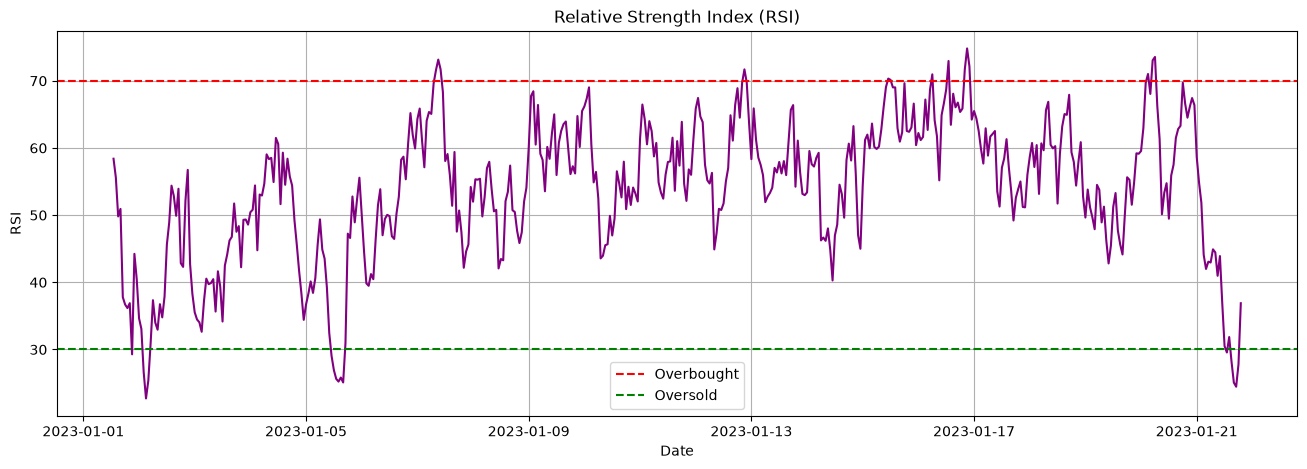

In [9]:
plt.figure(figsize=(16,5))

plt.plot(price["DateTime"], price["RSI"], color="purple")

plt.axhline(70, color="red", linestyle="--", label="Overbought")

plt.axhline(30, color="green", linestyle="--", label="Oversold")

plt.title("Relative Strength Index (RSI)")

plt.xlabel("Date")

plt.ylabel("RSI")

plt.legend()

plt.grid(True)

plt.show()

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ta.momentum import RSIIndicator
from ta.trend import MACD

In [11]:
price = pd.read_csv("../data/forex_price_data.csv")

price["DateTime"] = pd.to_datetime(price["DateTime"])

price.head()

,DateTime,PairID,PairName,Open,High,Low,Close,Volume,Spread
0,2023-01-01 00:00:00,1,EUR/USD,1.08103,1.08103,1.08019,1.08054,2651,0.9
1,2023-01-01 01:00:00,1,EUR/USD,1.08010,1.08043,1.07974,1.08028,2292,1.0
2,2023-01-01 02:00:00,1,EUR/USD,1.08036,1.08158,1.07961,1.08054,1796,1.2
3,2023-01-01 03:00:00,1,EUR/USD,1.08068,1.08126,1.07973,1.08088,4019,1.4
4,2023-01-01 04:00:00,1,EUR/USD,1.08042,1.08042,1.07967,1.08030,2207,1.6


In [12]:
price["MA_5"] = price["Close"].rolling(window=5).mean()

price["MA_20"] = price["Close"].rolling(window=20).mean()

price["Price_Change"] = price["Close"] - price["Open"]

price["High_Low_Range"] = price["High"] - price["Low"]

price["Return"] = price["Close"].pct_change()

In [13]:
price["RSI"] = RSIIndicator(
    close=price["Close"],
    window=14
).rsi()

price[["Close", "RSI"]].tail()

,Close,RSI
495,1.10861,28.186279
496,1.10739,25.076850
497,1.10713,24.457616
498,1.10758,27.781563
499,1.10895,36.886526


In [14]:
macd = MACD(close=price["Close"])

price["MACD"] = macd.macd()

price["MACD_Signal"] = macd.macd_signal()

price["MACD_Histogram"] = macd.macd_diff()

price[[
    "Close",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram"
]].tail()

,Close,MACD,MACD_Signal,MACD_Histogram
495,1.10861,-0.001262,-0.000544,-0.000718
496,1.10739,-0.001505,-0.000737,-0.000769
497,1.10713,-0.001700,-0.000929,-0.000770
498,1.10758,-0.001796,-0.001103,-0.000694
499,1.10895,-0.001742,-0.001231,-0.000512


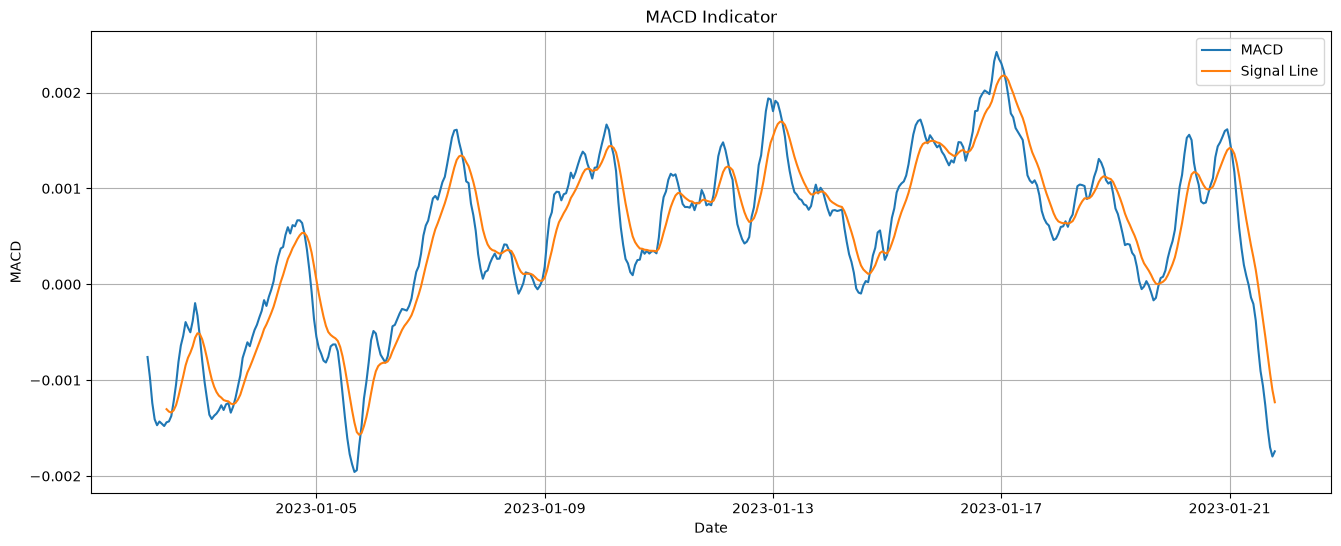

In [15]:
plt.figure(figsize=(16,6))

plt.plot(price["DateTime"], price["MACD"], label="MACD")

plt.plot(price["DateTime"], price["MACD_Signal"], label="Signal Line")

plt.title("MACD Indicator")

plt.xlabel("Date")

plt.ylabel("MACD")

plt.legend()

plt.grid(True)

plt.show()

In [16]:
from ta.volatility import BollingerBands

In [17]:
bb = BollingerBands(
    close=price["Close"],
    window=20,
    window_dev=2
)

price["BB_Middle"] = bb.bollinger_mavg()
price["BB_Upper"] = bb.bollinger_hband()
price["BB_Lower"] = bb.bollinger_lband()

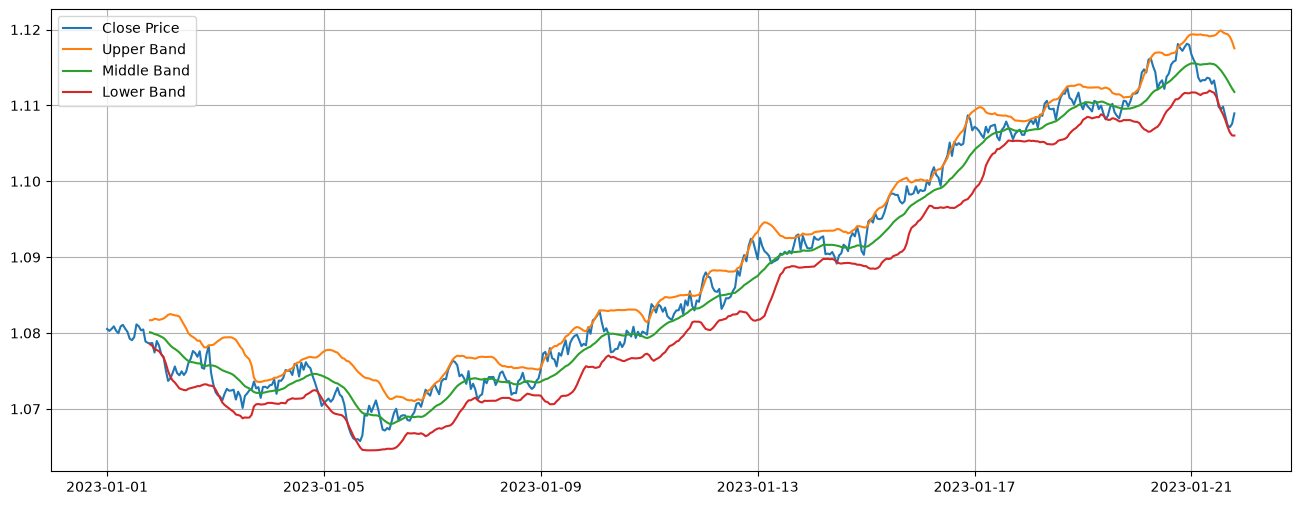

In [18]:
plt.figure(figsize=(16,6))

plt.plot(price["DateTime"], price["Close"], label="Close Price")
plt.plot(price["DateTime"], price["BB_Upper"], label="Upper Band")
plt.plot(price["DateTime"], price["BB_Middle"], label="Middle Band")
plt.plot(price["DateTime"], price["BB_Lower"], label="Lower Band")

plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Save feature engineered dataset for Power BI

price.to_csv(
    "../data/forex_price_features.csv",
    index=False
)

print("Feature engineered dataset exported successfully!")

Feature engineered dataset exported successfully!
